In [1]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
!curl https://zenodo.org/records/2603256/files/train.h5?download=1 -o toptag_train.h5
!curl https://zenodo.org/records/2603256/files/val.h5?download=1 -o toptag_val.h5
!curl https://zenodo.org/records/2603256/files/test.h5?download=1 -o toptag_test.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  990M  100  990M    0     0  8931k      0  0:01:53  0:01:53 --:--:-- 7713k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  13.7M      0  0:00:24  0:00:24 --:--:-- 14.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  17.1M      0  0:00:19  0:00:19 --:--:-- 17.7M


In [2]:
fileIN_train = "toptag_train.h5"
fileIN_val = "toptag_val.h5"
fileIN_test = "toptag_test.h5"

f_train = h5py.File(fileIN_train)
# and see what it contains
print(list(f_train.keys()))

['table']


In [3]:
df_train = pd.read_hdf(fileIN_train, 'table')
df_val = pd.read_hdf(fileIN_val, 'table')
df_test = pd.read_hdf(fileIN_test, 'table')
df_train

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
375,474.071136,-250.347031,-223.651962,-334.738098,103.236237,-48.866222,-56.790775,-71.025490,105.255569,-55.415001,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
377,150.504532,120.062393,76.852005,-48.274265,82.257057,63.801739,42.754807,-29.454842,48.573559,36.763199,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
378,251.645386,10.427651,-147.573746,203.564880,104.147797,10.718256,-54.497948,88.101395,78.043213,5.724113,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
379,451.566132,129.885437,-99.066292,-420.984100,208.410919,59.033958,-46.177090,-194.467941,190.183304,54.069675,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
380,399.093903,-168.432083,-47.205597,-358.717438,273.691956,-121.926941,-30.803854,-243.088928,152.837219,-44.400204,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,206.171997,13.942102,114.328499,-171.001465,231.602356,19.010832,92.303848,-211.561432,95.868248,0.411594,...,0.0,0.0,0.0,0.0,1301.364624,48.551048,674.270081,-1098.891968,0,1
591,263.984161,-40.649391,-104.321312,239.065552,238.690689,8.786323,-101.236137,215.979828,126.197868,5.939164,...,0.0,0.0,0.0,0.0,1550.415405,-38.385075,-626.145813,1406.682983,0,1
592,61.417538,42.901291,43.947723,-0.436818,45.521763,31.723654,32.643845,-0.469300,44.801167,29.730831,...,0.0,0.0,0.0,0.0,654.942383,394.933441,467.778076,-162.717285,0,1
593,261.215302,12.780115,-132.699203,224.635300,224.066376,52.028233,-101.145271,193.050354,67.573616,17.166769,...,0.0,0.0,0.0,0.0,1100.826904,220.153702,-566.737549,901.328003,0,1


In [4]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model

class JetDataset(Dataset):

    def __init__(self, df):

        self.jets = list()
        self.labels = list()
        for index, row in df.iterrows():

            tensor = torch.tensor(row.values, dtype=torch.float)
            self.jets.append(tensor[:-6].reshape(-1, 4))
            self.labels.append(tensor[-1].item())

    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index]


In [5]:
# constituent of each jet is ordered from large to small energy
dataset_train = JetDataset(df_train)
dataset_val = JetDataset(df_val)
dataset_test = JetDataset(df_test)

In [6]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)
        
        self.history = dict()
        
    def forward(self, Q, K, masks):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)
        
        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)
        
        self.history["Q"] = Q_.detach()
        self.history["K"] = K_.detach()
        self.history["V"] = V_.detach()
        
        A_pre = Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V)
        
        if masks is not None:
            A_pre += masks
        
        A = torch.softmax(A_pre, 2)
        
        self.history["A"] = A.detach()
        
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O
                
        
class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X, masks):
        return self.mab(X, X, masks)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.mask = None
        self.num_heads = num_heads
        self.enc = SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias)
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden, 64, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(64,16, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(16,dim_output, bias = bias),
        )
        self.history = self.enc.mab.history
    
    def make_mask(self, batch_size, mask):
        
        self.mask = torch.full((batch_size, self.num_heads, 200, 200), 0)
        
        for batch in range(batch_size):
            for head in range(self.num_heads):
                for mm in mask[head]:
                    x,y = mm
                    self.mask[batch, head, x, y] = 1e16*-1
        self.mask = model.mask.reshape(-1, 200, 200)
        
    def forward(self, X):
        X_ = self.pool(self.enc(X, self.mask).transpose(1, 2)).squeeze(dim=-1)
        X_ = self.fc(self.norm(X_))
        return X_

In [7]:
torch.cuda.is_available()

True

In [8]:
# define model, dataloaders, optimizers, etc.
device = "cuda" if torch.cuda.is_available() else "cpu"

dim_in = 4
dim_output = 1
num_particles_per_jet = 200
num_heads = 3
dim_hidden = 16*num_heads
bias = False

model = SetTransformer(dim_in, dim_output, num_particles_per_jet, dim_hidden=dim_hidden, num_heads = num_heads, bias = bias).to(device)

train_dataloader = DataLoader(dataset_train, batch_size=2, shuffle=True)

model.load_state_dict(torch.load('./1layer_set_transformer_topquarktag_3heads_nobias.pt'))

<All keys matched successfully>

In [9]:
def get_num_valid_particles(X):
    X_ = (X > 0)
    X_ = torch.sum(X_, 1)
    for i in range(X_.shape[-1]):
        if X_[i] <= 0:
            break
    return i

iterator = iter(train_dataloader)

In [10]:
X, y = next(iterator)
X = X.to(device)
y = y.to(device)
print(y)
model(X)

tensor([1., 0.], device='cuda:0', dtype=torch.float64)


tensor([[-1.1394],
        [-0.7170]], device='cuda:0', grad_fn=<MmBackward0>)

end_index:  49
true label:  1.0


<Axes: >

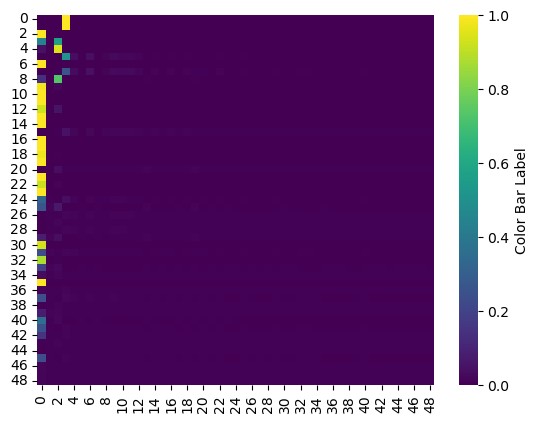

In [11]:
import seaborn as sns

batch_idx = 0
end_index = get_num_valid_particles(X[batch_idx])
attention_heads_idx = [0,1,2] if batch_idx == 0 else [3,4,5]

print("end_index: ", end_index)
print("true label: ", y[batch_idx].item())

# attention_score = (model.history[0]["Q"][0,...] @ model.history[0]["K"][0,...].T).detach().cpu().numpy()
attention_score = model.history["A"][attention_heads_idx[0], :end_index, :end_index].detach().cpu().numpy()
sns.heatmap(attention_score, annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

<Axes: >

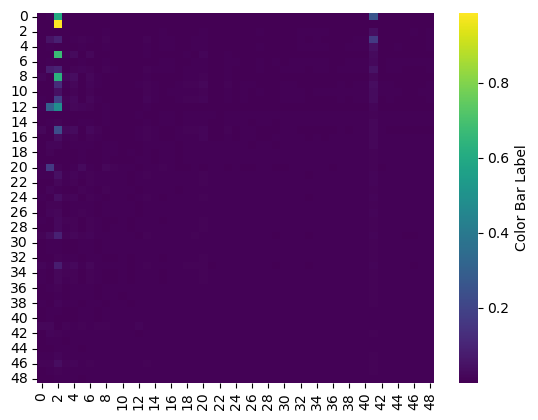

In [12]:
attention_score = model.history["A"][attention_heads_idx[1], :end_index, :end_index].detach().cpu().numpy()
sns.heatmap(attention_score, annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

<Axes: >

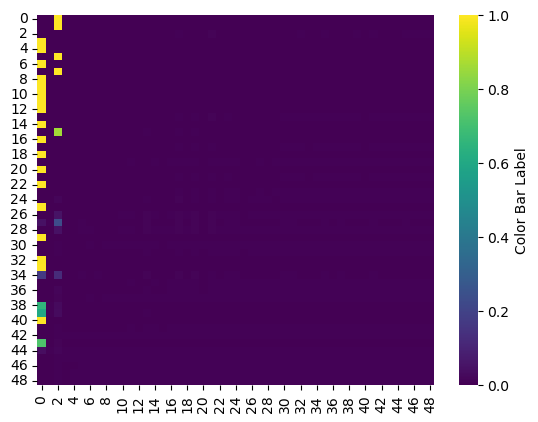

In [13]:
attention_score = model.history["A"][attention_heads_idx[2], :end_index, :end_index].detach().cpu().numpy()
sns.heatmap(attention_score, annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

In [14]:
attention_score = torch.softmax(model.history["Q"].bmm(model.history["K"].transpose(1,2)), 2)
print(attention_score[0][100:200, 100:200])
print(model.history["A"][0][100:200, 100:200])
# sns.heatmap(attention_score, annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

tensor([[0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        ...,
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050]],
       device='cuda:0')
tensor([[0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        ...,
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050]],
       device='cuda:0')


In [14]:
import seaborn as sns

In [11]:
from tqdm import tqdm
mask_flag = False
mask = {0:[[11,0],[10,0]], 1:[[11,0],[10,0]], 2:[[11,0],[12,0]]}

In [28]:
batch_size = 512
test_dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

if mask_flag == False:
    model.make_mask(batch_size, mask)
    model.mask = model.mask.to(device)
    
model.eval()

attention_maps = {k:list() for k in range(num_heads)}

for b in tqdm(test_dataloader):
    
    X, y = b
    cur_batch_size = X.shape[0]
    
    if cur_batch_size != batch_size and model.mask is not None:
        model.make_mask(cur_batch_size, mask)
        model.mask = model.mask.to(device)
        
    X = X.to(device)
    y = y.to(device)
    
    with torch.no_grad():
        model(X)
        
    for batch in range(cur_batch_size):
        for head in range(num_heads):
            attention_maps[head].append(model.history["A"][batch*num_heads + head].detach().cpu())
    
    for head in range(num_heads):
        attention_maps[head] = [torch.sum(torch.stack(attention_maps[head],0), 0)]
        
mask_flag=False

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 790/790 [06:02<00:00,  2.18it/s]


<Axes: >

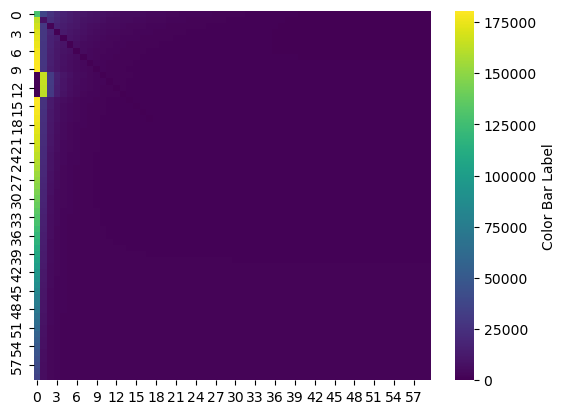

In [35]:
att1 = torch.stack(attention_maps[0])
att1_sum = torch.sum(att1, 0)
att1_sum_np = att1_sum.detach().cpu().numpy()
sns.heatmap(att1_sum_np[:60, :60], annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

<Axes: >

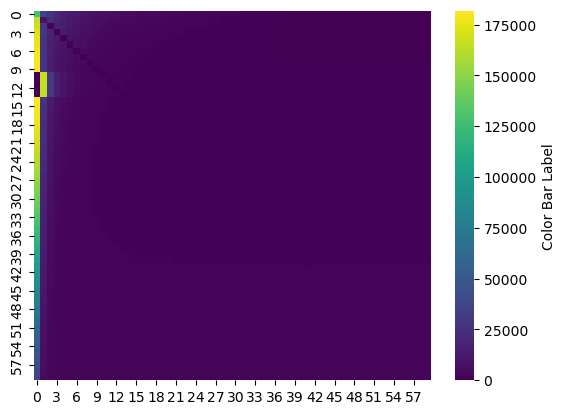

In [36]:
att2 = torch.stack(attention_maps[1])
att2_sum = torch.sum(att2, 0)
att2_sum_np = att2_sum.detach().cpu().numpy()
sns.heatmap(att2_sum_np[:60, :60], annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

<Axes: >

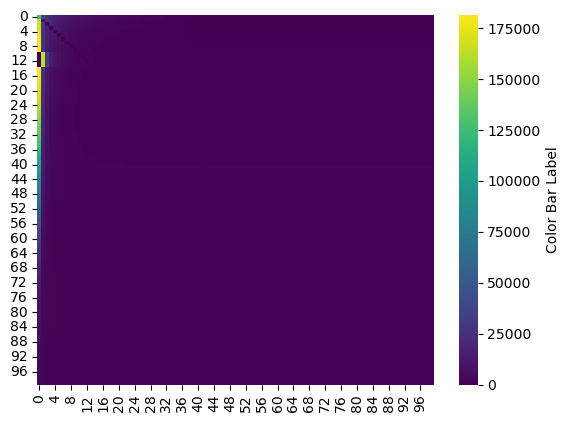

In [31]:
att3 = torch.stack(attention_maps[2])
att3_sum = torch.sum(att3, 0)
att3_sum_np = att3_sum.detach().cpu().numpy()
sns.heatmap(att3_sum_np[:100, :100], annot=False, cmap='viridis', cbar_kws={'label': 'Color Bar Label'})

In [32]:
argmax_idx = torch.argmax(att1_sum).detach().cpu().item()
argmax_2d_coord1 = argmax_idx // 200
argmax_2d_coord2 = argmax_idx % 200
print(f"{argmax_2d_coord1}, {argmax_2d_coord2}")
coord_pair1 = [argmax_2d_coord1, argmax_2d_coord2]

argmax_idx = torch.argmax(att2_sum).detach().cpu().item()
argmax_2d_coord1 = argmax_idx // 200
argmax_2d_coord2 = argmax_idx % 200
print(f"{argmax_2d_coord1}, {argmax_2d_coord2}")
coord_pair2 = [argmax_2d_coord1, argmax_2d_coord2]

argmax_idx = torch.argmax(att3_sum).detach().cpu().item()
argmax_2d_coord1 = argmax_idx // 200
argmax_2d_coord2 = argmax_idx % 200
print(f"{argmax_2d_coord1}, {argmax_2d_coord2}")
coord_pair3 = [argmax_2d_coord1, argmax_2d_coord2]

9, 0
14, 0
9, 0


In [33]:
mask[0].append(coord_pair1)
mask[1].append(coord_pair2)
mask[2].append(coord_pair3)
print(mask)
model.make_mask(batch_size, mask)
model.mask = model.mask.to(device)

{0: [[11, 0], [10, 0], [12, 0], [13, 0], [9, 0]], 1: [[11, 0], [10, 0], [12, 0], [13, 0], [14, 0]], 2: [[11, 0], [12, 0], [13, 0], [10, 0], [9, 0]]}


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 790/790 [00:10<00:00, 74.42it/s]


Test set loss: 0.23866756273768955
Test accuracy: 0.8977376237623762


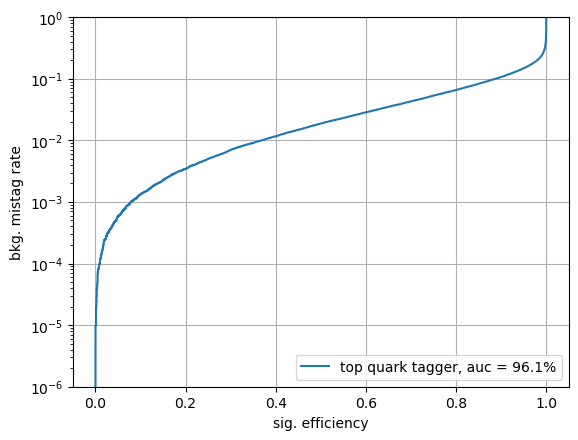

In [34]:
# testing on test set

model.eval()
test_dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)
m = nn.Sigmoid()
mm = nn.BCELoss()

test_losses = []
test_logits = []
test_labels_true = []
test_num_correct = 0
with torch.no_grad():

    for batch in tqdm(test_dataloader):

        X, y = batch
        
        if X.shape[0] != batch_size:
            model.make_mask(X.shape[0], mask)
            model.mask = model.mask.to(device)
            
        X = X.to(device)
        y = y.to(device)
        
        output = model(X).squeeze(dim=1).to(torch.float64)

        predicted_labels = (output >= 0.5)

        loss = mm(m(output), y)

        test_labels_true.extend(list(y.to(torch.long).detach().cpu().numpy()))
        test_logits.extend(list(output.detach().cpu().numpy()))
        test_losses.append(loss.item())
        test_num_correct += torch.sum(y == predicted_labels).item()

print(f"Test set loss: {sum(test_losses)/len(test_losses)}")
print(f"Test accuracy: {test_num_correct / len(dataset_test)}")

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

df = pd.DataFrame()
fpr = {}
tpr = {}
auc1 = {}

plt.figure()

fpr, tpr, threshold = roc_curve(np.array(test_labels_true), np.array(test_logits))

auc1 = auc(fpr, tpr)

plt.plot(tpr,fpr,label='%s tagger, auc = %.1f%%'%("top quark",auc1*100.))

plt.semilogy()
plt.xlabel("sig. efficiency")
plt.ylabel("bkg. mistag rate")
plt.ylim(0.000001,1)
plt.grid(True)
plt.legend(loc='lower right')
plt.show()


In [15]:
from tqdm import tqdm

In [16]:
batch_size = 16
num_samples_max = 10000
num_samples = 0
over_limit_count = 0

hist_bins_head1 = {}
hist_bins_head2 = {}
hist_bins_head3 = {}
hist_bins_top = {0:dict(), 1:dict(), 2:dict()}
hist_bins_qcd = {0:dict(), 1:dict(), 2:dict()}
count_top = 0
count_qcd = 0
for kk in range(3):
    for i in range(100):
        for j in range(100):
            # hist_bins_head1[kk][f"({i}, {j})"] = list()
            # hist_bins_head2[kk][f"({i}, {j})"] = list()
            # hist_bins_head3[kk][f"({i}, {j})"] = list()
            hist_bins_top[kk][f"({i}, {j})"] = list()
            hist_bins_qcd[kk][f"({i}, {j})"] = list()
        
test_dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

model.mask = None

model.eval()

for b in tqdm(test_dataloader):
    if num_samples > num_samples_max:
        break
        
    num_samples += 1
        
    X, y = b
    
    terminal_indices = []
    for k in range(batch_size):
        terminal_indices.append(get_num_valid_particles(X[k]))
        
    X = X.to(device)
    y = y.to(device)
    
    with torch.no_grad():
        model(X)
    
    for batch in range(batch_size):
        
        limit = terminal_indices[batch]
        
        if limit >= 100: 
            over_limit_count += 1
            continue
            
        if int(y[batch].item()) == 1:
            count_top += 1
            
        if int(y[batch].item()) == 0:
            count_qcd += 1
            
        for head in range(num_heads):
            for i in range(limit):
                for j in range(limit):
                    entry = model.history["A"][batch*num_heads + head, i, j].detach().cpu().item()
                    # if head == 0:
                    if int(y[batch].item()) == 1:
                        hist_bins_top[head][f"({i}, {j})"].append(entry)
                    if int(y[batch].item()) == 0:
                        hist_bins_qcd[head][f"({i}, {j})"].append(entry)
                        
                        # hist_bins_head1[f"({i}, {j})"].append(entry)
                    # if head == 1:
                        # hist_bins_head2[f"({i}, {j})"].append(entry)
                    # if head == 2:
                        # hist_bins_head3[f"({i}, {j})"].append(entry)

                    # if int(y[batch].item()) == 1:
                        # hist_bins_top[f"({i}, {j})"].append(entry)
                    # if int(y[batch].item()) == 0:
                        # hist_bins_qcd[f"({i}, {j})"].append(entry)


  1%|▊                                                                                                                              | 162/25250 [30:49<79:34:11, 11.42s/it]


KeyboardInterrupt: 

In [25]:
print(count_top)
print(count_qcd)
print(over_limit_count)

1340
1248
19


In [18]:
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np

# Generate random data
data_head1_top = []
data_head2_top = []
data_head3_top = []
data_head1_qcd = []
data_head2_qcd = []
data_head3_qcd = []

bin_labels = []
for i in range(100):
    for j in range(100):
        bin_labels.append(f"({i}, {j})")
        
        data1_top = np.array(hist_bins_top[0][f"({i}, {j})"])
        data2_top = np.array(hist_bins_top[1][f"({i}, {j})"])
        data3_top = np.array(hist_bins_top[2][f"({i}, {j})"])
        
        data1_qcd = np.array(hist_bins_qcd[0][f"({i}, {j})"])
        data2_qcd = np.array(hist_bins_qcd[1][f"({i}, {j})"])
        data3_qcd = np.array(hist_bins_qcd[2][f"({i}, {j})"])
        
        data_head1_top.append(np.sum(data1_top > 1e-10))
        data_head2_top.append(np.sum(data2_top > 1e-10))
        data_head3_top.append(np.sum(data3_top > 1e-10))
        
        data_head1_qcd.append(np.sum(data1_qcd > 1e-10))
        data_head2_qcd.append(np.sum(data2_qcd > 1e-10))
        data_head3_qcd.append(np.sum(data3_qcd > 1e-10))

        

<Axes: >

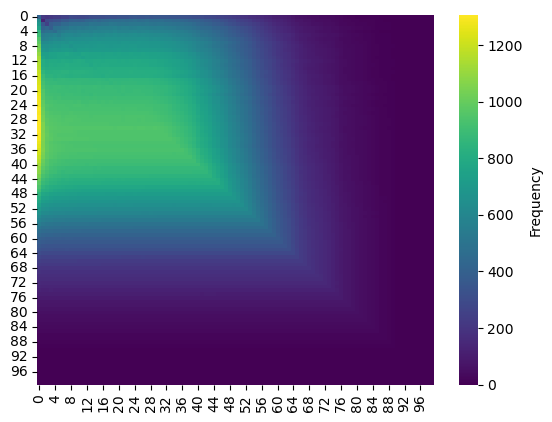

In [19]:
import seaborn as sns
data_head1_top_matrix = np.reshape(np.array(data_head1_top), (100,100))
data_head2_top_matrix = np.reshape(np.array(data_head2_top), (100,100))
data_head3_top_matrix = np.reshape(np.array(data_head3_top), (100,100))

data_head1_qcd_matrix = np.reshape(np.array(data_head1_qcd), (100,100))
data_head2_qcd_matrix = np.reshape(np.array(data_head2_qcd), (100,100))
data_head3_qcd_matrix = np.reshape(np.array(data_head3_qcd), (100,100))

sns.heatmap(data_head1_top_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

<Axes: >

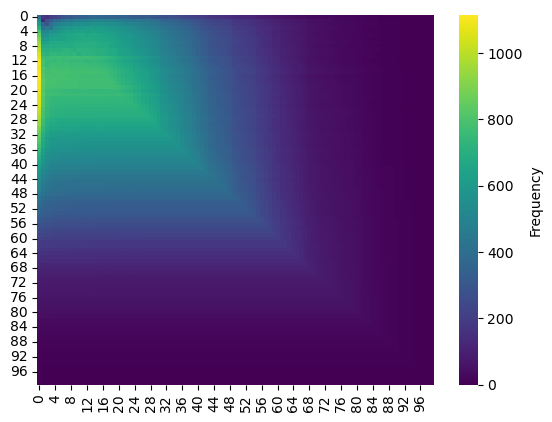

In [30]:
sns.heatmap(data_head1_qcd_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

<Axes: >

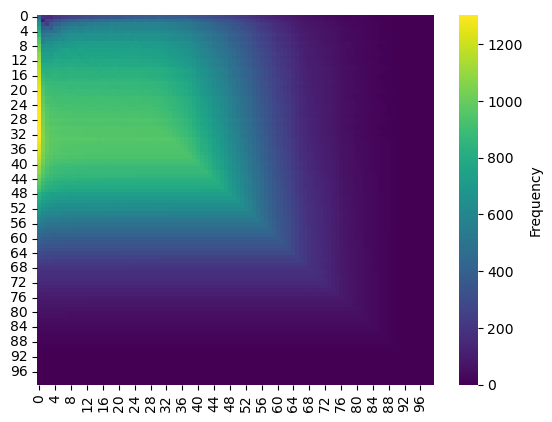

In [29]:
sns.heatmap(data_head2_top_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

<Axes: >

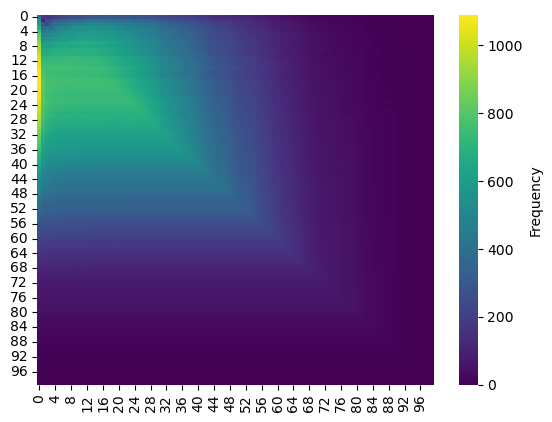

In [22]:
sns.heatmap(data_head2_qcd_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

<Axes: >

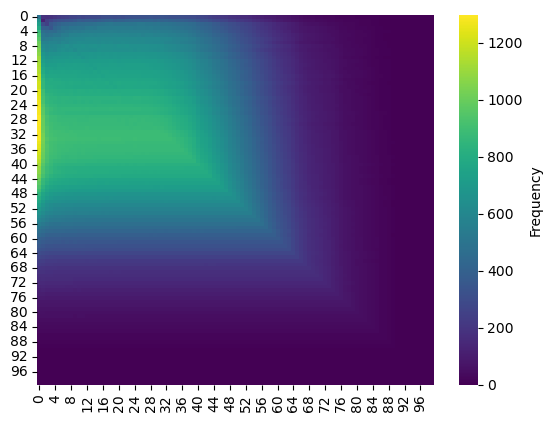

In [23]:
sns.heatmap(data_head3_top_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

<Axes: >

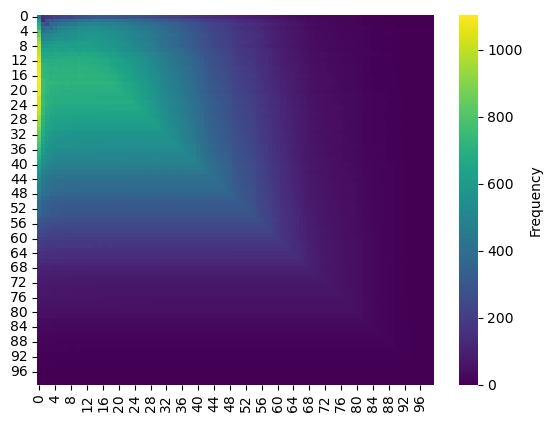

In [24]:
sns.heatmap(data_head3_qcd_matrix, annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

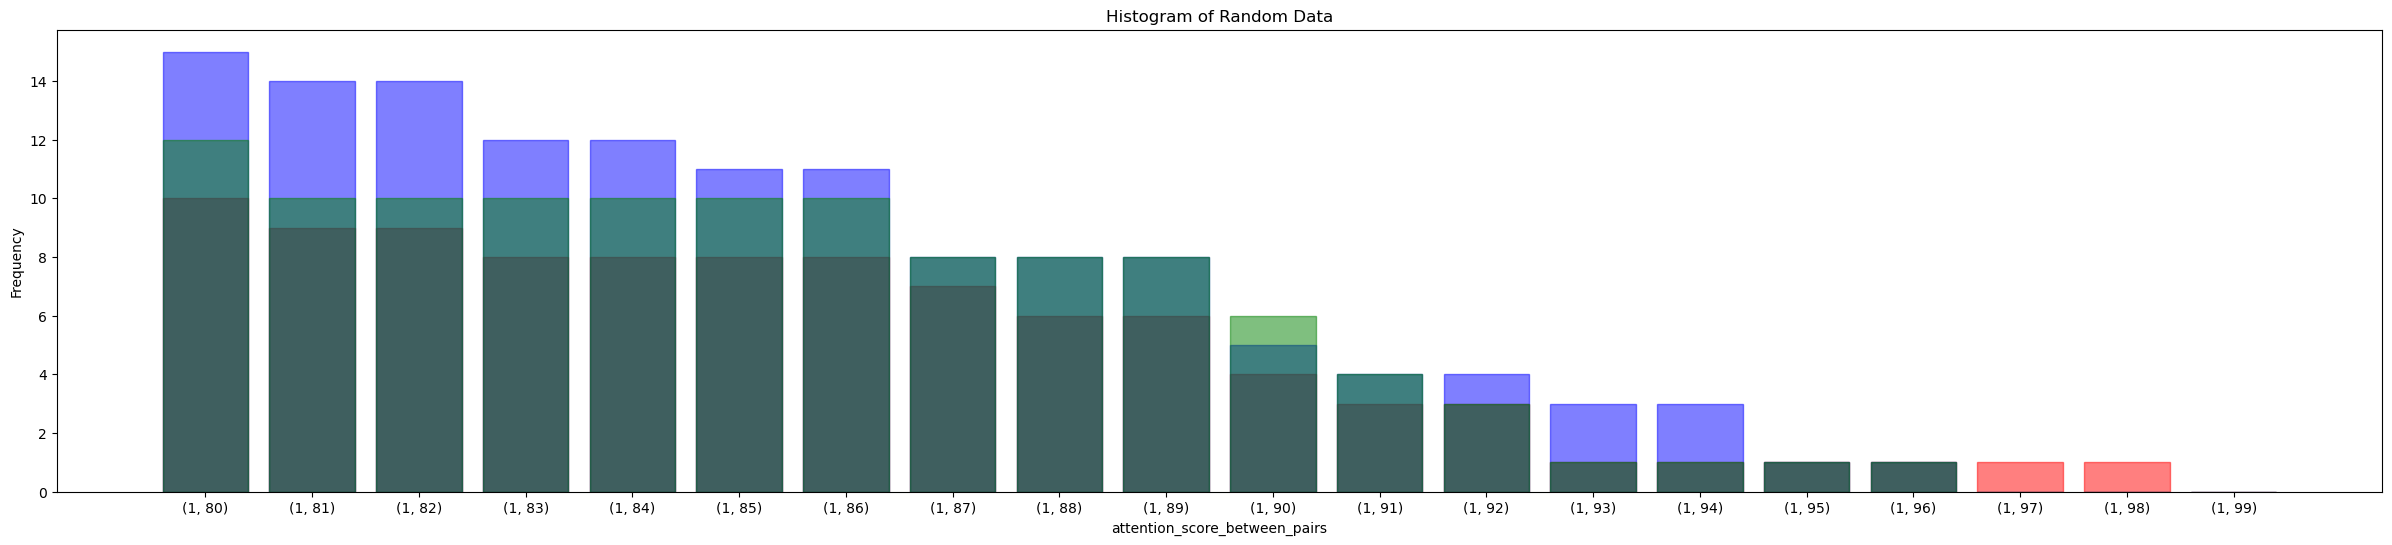

In [65]:
plt.figure(figsize=(30, 6))

# Plot the histogram
start_idx = 180
end_idx = 200
plt.bar(bin_labels[start_idx:end_idx], data_head1[start_idx:end_idx], alpha=0.5, color="red", edgecolor='red')
plt.bar(bin_labels[start_idx:end_idx], data_head2[start_idx:end_idx], alpha=0.5, color="blue", edgecolor='blue')
plt.bar(bin_labels[start_idx:end_idx], data_head3[start_idx:end_idx], alpha=0.5, color="green", edgecolor='green')

# Add titles and labels
plt.title('Histogram of Random Data')
plt.xlabel('attention_score_between_pairs')
plt.ylabel('Frequency')

# Show the plot
plt.show()

<Axes: >

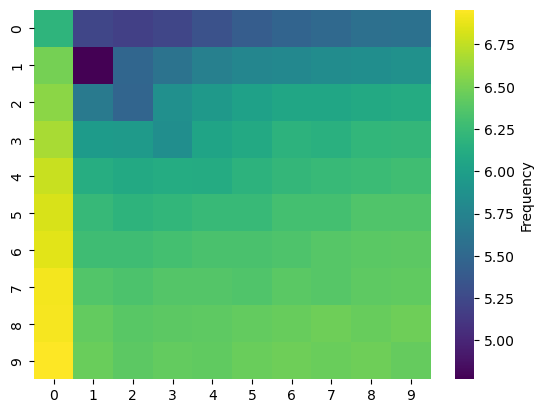

In [45]:
sns.heatmap(np.log(data_head3_top_matrix)[:10, :10], annot=False, cmap='viridis', cbar_kws={'label': 'Frequency'})

In [42]:
np.log(data_head3_top_matrix)[:, 90:]

array([[0.        , 0.        , 0.        ,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [      -inf,       -inf,       -inf,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [      -inf,       -inf,       -inf,       -inf,       -inf,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.69314718, 0.        , 0.        , 0.        , 0.        ,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.69314718, 0.69314718, 0.69314718, 0.        , 0.        ,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.69314718, 0.69314718, 0.69314718, 0.        , 0.        ,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.69314718, 0.69314718, 0.69314718, 0.        , 0.        ,
              -inf,       -inf,       -inf,       -inf,       -inf],
       [0.        , 0.        , 0.       